In [ ]:
# # Google Colab Setup (Comment out for local computer running)
################################################################################
# Uncomment and set the path to your project folder in Google Drive
################################################################################
# from google.colab import drive
# drive.mount('/content/drive')

# FOLDERNAME = 'cpsc8430/assignments/project3/'
# assert FOLDERNAME is not None, "[!] Enter the foldername."

# import sys
# sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))
# %cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/cpsc8430/assignments/project3


# Project 3: Convolutional Neural Networks (CNNs) in PyTorch

In this project, you will explore CNNs for image classification and understand key components that make deep learning effective. You'll implement CNN architectures, compare training techniques, and apply transfer learning.

By the end, you should be able to:
- Build and train **CNNs** for image classification tasks
- Understand how **batch normalization** and **advanced optimizers** improve training
- Implement **ResNet/residual blocks** and apply **regularization** techniques
- Perform **transfer learning** using pretrained models
- Apply CNNs to **object detection** and **image segmentation**

***NOTE:***
When filling in the code, please REMOVE the `pass` and `None` statement.
DO NOT remove the TODO coding highlight in your submission.

### <span style="color: red;"> Grading Criteria for This Notebook (Part 1):</span>
- Code quality and implementation (2 pts)
- Performance benchmarks (achieve ≥56% accuracy on Caltech-101) (2 pts)
- Analysis and answers to inline questions (2 pts)
- **Total for this notebook: 6 points**

**Note on Performance:** Caltech-101 is more challenging than CIFAR-10 due to having 101 classes and varying image complexities. A baseline accuracy of ≥56% demonstrates good understanding of CNN fundamentals.

### <span style="color: blue;"> Overall Project 3 Grading (24 points total):</span>
- **Part 1**: CNN Fundamentals (this notebook) - 6 points
- **Part 2**: Transfer Learning - 6 points
- **Part 3**: Object Detection (Faster R-CNN) - 6 points
- **Part 4**: Image Segmentation (U-Net) - 6 points

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set style for better plots
plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style('whitegrid')

Using device: cpu


## Part 1: Load and Preprocess Caltech-101 Dataset

We'll use Caltech-101, a dataset of images belonging to 101 categories, with about 40 to 800 images per category. The images will be resized to 32x32 to keep training fast while learning CNN fundamentals.

**Dataset Reference:** [Caltech-101](https://data.caltech.edu/records/mzrjq-6wc02)

Using Caltech-101 Dataset
Dataset source: https://data.caltech.edu/records/mzrjq-6wc02
------------------------------------------------------------
✓ Caltech-101 dataset (object categories) already exists

Loading Caltech-101 with ImageFolder...
✓ Dataset loaded successfully from cpsc8430/datasets/caltech101/caltech-101/101_ObjectCategories!
Total samples in Caltech-101: 9144
Number of categories: 102
------------------------------------------------------------
Dataset: Caltech-101 (loaded with ImageFolder)
Training samples: 7315
Test samples: 1829
Number of classes: 102
Batch size: 128
Image size after transform: 32x32
------------------------------------------------------------
Number of classes: 102


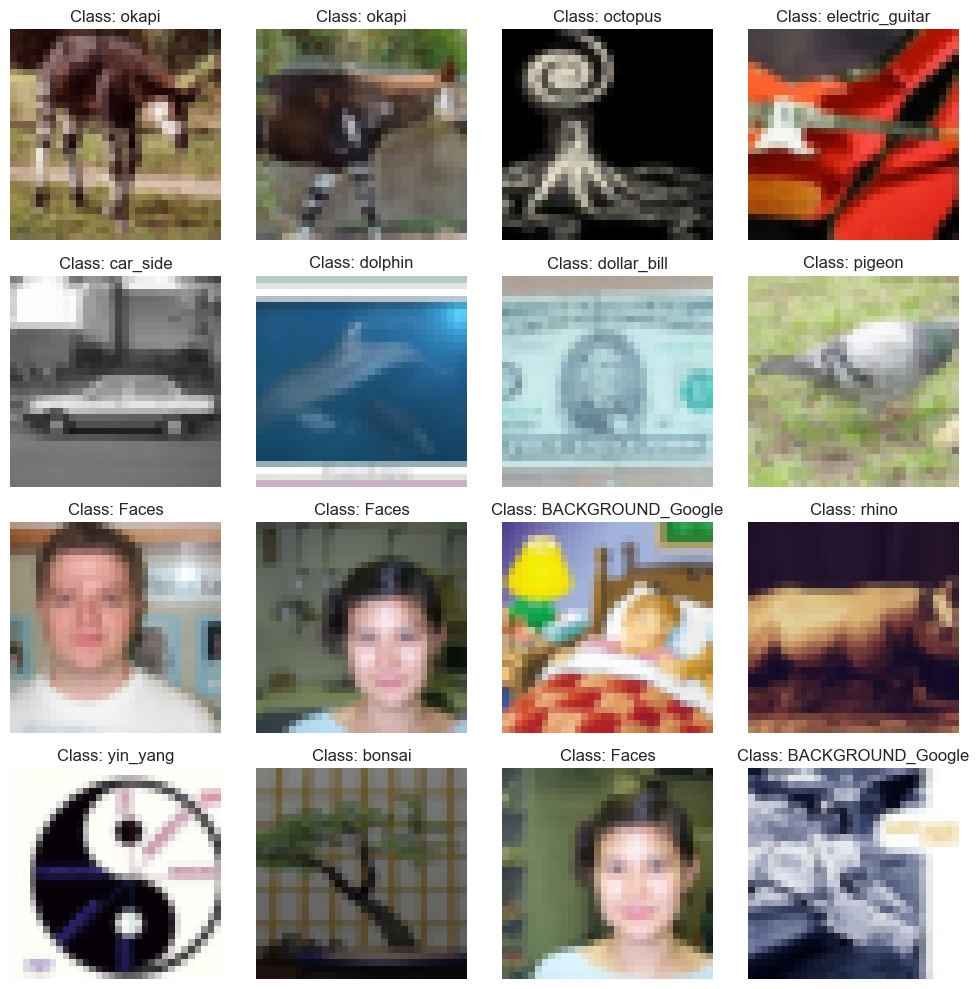

In [5]:
# Import data loading utility
import sys
sys.path.append('cpsc8430')
from data_utils import load_caltech101, denormalize_standard

# Load Caltech-101 dataset with 32x32 images for CNN fundamentals
# Data will be automatically downloaded if not present
train_loader, test_loader, num_classes, class_names = load_caltech101(
    data_root='cpsc8430/datasets',
    batch_size=128,
    num_workers=0, # MacOS requires this to be 0 to work
    image_size=32,  # Resize to 32x32 for faster training
    train_split=0.8,
    random_seed=42
)

print(f'Number of classes: {num_classes}')

# Visualize some sample Caltech-101 images

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
# Get a batch from test set
images, labels, text_labels = next(iter(test_loader))

for i in range(16):
    ax = axes[i // 4, i % 4]
    # Denormalize for visualization
    img_denorm = denormalize_standard(images[i])
    ax.imshow(img_denorm.permute(1, 2, 0))
    # Use text label for the title
    ax.set_title(f'Class: {text_labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Part 2: Implement Basic CNN Architecture

**TODO: Implement a basic CNN for image classification**

The CNN should:
- Use convolutional layers to extract spatial features
- Apply pooling layers to reduce spatial dimensions
- Use fully connected layers for classification
- Include ReLU activations

In [10]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=101):
        """
        Basic CNN implementation for Caltech-101

        Args:
            num_classes (int): Number of output classes (101 for Caltech-101)
        """
        super(BasicCNN, self).__init__()

        ################################################################################
        # TODO: Implement CNN architecture
        # HINT: Use Conv2d, MaxPool2d, and Linear layers
        # Suggested architecture:
        # - Conv1: 3 input channels, 32 output channels, 3x3 kernel
        # - Conv2: 32 input channels, 64 output channels, 3x3 kernel
        # - Pool: 2x2 max pooling
        # - Conv3: 64 input channels, 128 output channels, 3x3 kernel
        # - Pool: 2x2 max pooling
        # - FC layers to map to num_classes
        ################################################################################
        # *****START OF YOUR CODE*****
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        """
        Forward pass of the CNN

        Args:
            x: Input tensor of shape (batch_size, 3, 32, 32)

        Returns:
            Output tensor of shape (batch_size, num_classes)
        """
        ################################################################################
        # TODO: Implement forward pass
        # HINT: Apply conv layers with ReLU and pooling, then flatten and pass through FC layers
        ################################################################################
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)  
        x = F.relu(self.conv3(x))
        x = self.pool2(x)  
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        # *****END OF YOUR CODE*****
        ################################################################################

    def get_num_parameters(self):
        """Return the total number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test the model
model = BasicCNN(num_classes=num_classes)
print(f'Model architecture:\n{model}')
print(f'Number of parameters: {model.get_num_parameters():,}')

# Test forward pass
sample_batch = torch.randn(32, 3, 32, 32)
output = model(sample_batch)
print(f'Input shape: {sample_batch.shape}')
print(f'Output shape: {output.shape}')

Model architecture:
BasicCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=102, bias=True)
)
Number of parameters: 4,340,390
Input shape: torch.Size([32, 3, 32, 32])
Output shape: torch.Size([32, 102])


### Question 1: CNN Architecture

**a) Explain the role of convolutional layers in CNNs. How do they differ from fully connected layers in MLPs? What advantages do convolutional layers provide for image data?**

$\color{blue}{\textit{Your Answer:}}$

There are a few difference. We could probably sum it up with the following:
1. *Convolutional layers* are locally connected while *fully connected layers* are globally connected.
2. *Convolutional layers* share the same set of weights in the scanning area across the whole image, thus allowing for specific feature detections no matter which location the feature is in the image.
3. Lastly, the *convolutional layer* preserves the structure of the image, while the *fully connected layer* flattens to a 1D tensor, rendering spatial information useless.

**b) Calculate the output spatial dimensions after each convolutional and pooling layer in your BasicCNN. Show your work using the formula: output_size = (input_size - kernel_size + 2*padding) / stride + 1**

$\color{blue}{\textit{Your Answer:}}$

| Layer | Input | Formula | Output |
|---|---|---|---|
| Conv1 | $32 x 32$ | $(32 - 3 + 2 * 1)/1 + 1$ | $32 x 32$ |
| Conv2 | $32 x 32$ | $(32 - 3 + 2 * 1)/1 + 1$ | $32 x 32$ |
| Pool1 | $32 x 32$ | $(32 - 3 + 2 * 0)/2 + 1$ | $16 x 16$ |
| Conv3 | $16 x 16$ | $(16 - 3 + 2 * 1)/1 + 1$ | $16 x 16$ |
| Pool2 | $16 x 16$ | $(16 - 3 + 2 * 0)/2 + 1$ | $8 x 8$ |

## Part 3: Training and Evaluation Functions

These functions will be used throughout the experiments to train and evaluate different model configurations.

In [11]:
def train_model(model, train_loader, test_loader, optimizer, criterion, num_epochs=20, device='cpu', scheduler=None):
    """
    Train a model and return training history

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        optimizer: PyTorch optimizer
        criterion: Loss function
        num_epochs: Number of training epochs
        device: Device to train on ('cpu' or 'cuda')
        scheduler: Optional learning rate scheduler

    Returns:
        Dictionary containing training history
    """
    model = model.to(device)
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
        for data, targets, _ in train_pbar:
            data, targets = data.to(device), targets.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Statistics
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()

            train_pbar.set_postfix({'loss': loss.item(), 'acc': 100. * train_correct / train_total})

        # Evaluation phase
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for data, targets, _ in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)

                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                test_total += targets.size(0)
                test_correct += (predicted == targets).sum().item()

        # Calculate averages
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        train_accuracy = 100.0 * train_correct / train_total
        test_accuracy = 100.0 * test_correct / test_total

        # Store history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)
        history['test_loss'].append(avg_test_loss)
        history['test_acc'].append(test_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% - "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_accuracy:.2f}%")

        # Step the scheduler if provided
        if scheduler is not None:
            scheduler.step()

    return history


def plot_training_history(history, title="Training History"):
    """
    Plot training and validation curves
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['test_loss'], label='Test Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot accuracy
    ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
    ax2.plot(history['test_acc'], label='Test Accuracy', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

## Part 4: Train Basic CNN

Now let's train the basic CNN and establish a baseline performance.

EXPERIMENT 1: BASIC CNN WITHOUT BATCH NORMALIZATION


Epoch [1/20] - Train Loss: 3.9823, Train Acc: 17.28% - Test Loss: 3.5216, Test Acc: 23.89%


Epoch [2/20] - Train Loss: 3.4382, Train Acc: 26.17% - Test Loss: 3.1015, Test Acc: 28.98%


Epoch [3/20] - Train Loss: 3.1421, Train Acc: 29.79% - Test Loss: 2.8597, Test Acc: 33.02%


Epoch [4/20] - Train Loss: 2.9074, Train Acc: 33.06% - Test Loss: 2.8185, Test Acc: 32.80%


...

Epoch [16/20] - Train Loss: 1.7392, Train Acc: 55.39% - Test Loss: 1.9247, Test Acc: 52.98%


Epoch [17/20] - Train Loss: 1.6489, Train Acc: 57.22% - Test Loss: 1.9005, Test Acc: 51.83%


Epoch [18/20] - Train Loss: 1.6157, Train Acc: 57.87% - Test Loss: 1.8811, Test Acc: 52.38%


Epoch [19/20] - Train Loss: 1.5679, Train Acc: 59.08% - Test Loss: 1.8469, Test Acc: 53.42%


Epoch [20/20] - Train Loss: 1.5145, Train Acc: 60.40% - Test Loss: 1.9589, Test Acc: 52.49%


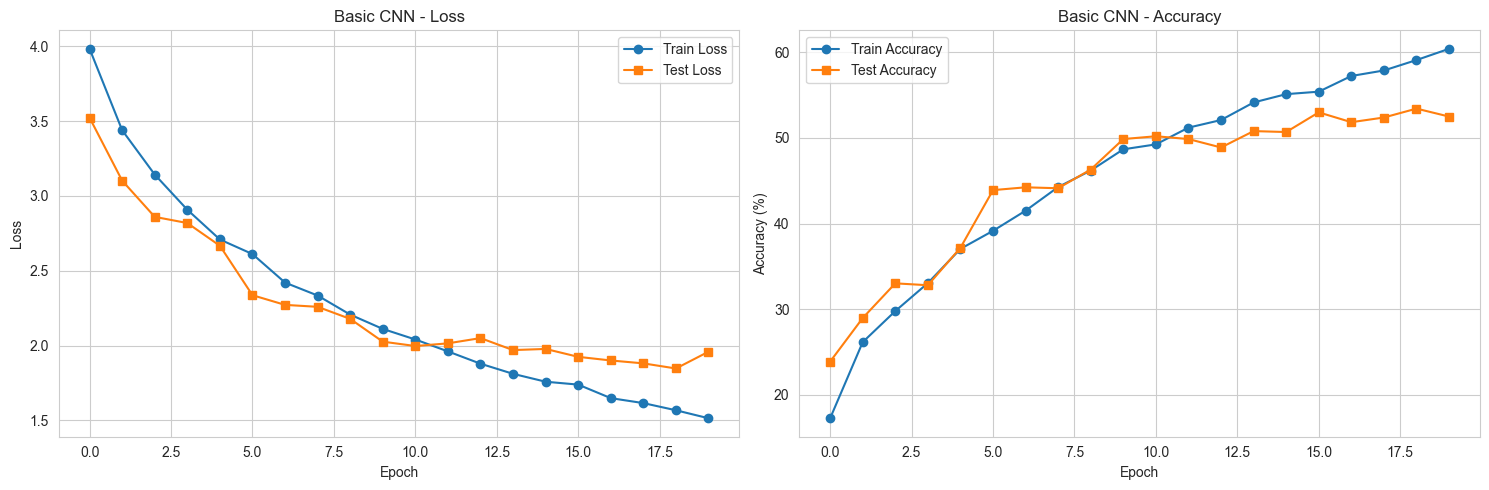


Final Test Accuracy: 52.49%


In [12]:
print("="*60)
print("EXPERIMENT 1: BASIC CNN WITHOUT BATCH NORMALIZATION")
print("="*60)

# Create model
model_basic = BasicCNN(num_classes=num_classes)
model_basic = model_basic.to(device)

# Define optimizer and loss
optimizer = optim.Adam(model_basic.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train the model
history_basic = train_model(
    model_basic, train_loader, test_loader,
    optimizer, criterion, num_epochs=20, device=device
)

# Plot results
plot_training_history(history_basic, "Basic CNN")

print(f"\nFinal Test Accuracy: {history_basic['test_acc'][-1]:.2f}%")

## Part 5: Batch Normalization and Advanced Optimizers

**TODO: Implement CNN with Batch Normalization**

Batch Normalization helps stabilize training by normalizing layer inputs, allowing for higher learning rates and faster convergence.

In [17]:
class CNN_BN(nn.Module):
    def __init__(self, num_classes=101):
        """
        CNN with Batch Normalization

        Args:
            num_classes (int): Number of output classes
        """
        super(CNN_BN, self).__init__()

        ################################################################################
        # TODO: Implement CNN with Batch Normalization
        # HINT: Add nn.BatchNorm2d after each convolutional layer
        # Use the same architecture as BasicCNN but add BatchNorm2d layers
        ################################################################################
        # *****START OF YOUR CODE*****
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.batchnorm1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.batchnorm2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.batchnorm3 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, num_classes)
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass with batch normalization
        # HINT: Apply conv -> bn -> relu -> pool pattern
        ################################################################################
        # *****START OF YOUR CODE*****
        x = F.relu(self.batchnorm1(self.conv1(x)))
        x = F.relu(self.batchnorm2(self.conv2(x)))
        x = self.pool1(x)  
        x = F.relu(self.batchnorm3(self.conv3(x)))
        x = self.pool2(x)  
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
        # *****END OF YOUR CODE*****
        ################################################################################

    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test the model
model_bn = CNN_BN(num_classes=num_classes)
print(f'Model with BN architecture:\n{model_bn}')
print(f'Number of parameters: {model_bn.get_num_parameters():,}')

Model with BN architecture:
CNN_BN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchnorm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchnorm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (batchnorm3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=102, bias=True)
)
Number of parameters: 4,340,838


### Compare different optimizers with and without Batch Normalization

In [22]:
print("\n" + "="*60)
print("EXPERIMENT 2: CNN WITH BATCH NORMALIZATION + Adam")
print("="*60)

################################################################################
# TODO: Train CNN_BN with Adam optimizer
# HINT: Create model_bn_adam, use Adam optimizer with lr=0.001
################################################################################
# *****START OF YOUR CODE*****
model_bn_adam = CNN_BN(num_classes=num_classes)
model_bn_adam = model_bn_adam.to(device)
optimizer_bn_adam = optim.Adam(model_bn_adam.parameters(), lr=0.001)
# *****END OF YOUR CODE*****
################################################################################

history_bn_adam = train_model(
    model_bn_adam, train_loader, test_loader,
    optimizer_bn_adam, criterion, num_epochs=20, device=device
)

print("\n" + "="*60)
print("EXPERIMENT 3: CNN WITH BATCH NORMALIZATION + SGD with Momentum")
print("="*60)

################################################################################
# TODO: Train CNN_BN with SGD + momentum
# HINT: Use SGD with lr=0.1, momentum=0.9
################################################################################
# *****START OF YOUR CODE*****
model_bn_sgd = CNN_BN(num_classes)
model_bn_sgd = model_bn_sgd.to(device)
optimizer_bn_sgd = optim.SGD(model_bn_sgd.parameters(), lr=0.01, momentum=0.95)
# *****END OF YOUR CODE*****
################################################################################

# Optional: Add learning rate scheduler
scheduler_sgd = optim.lr_scheduler.StepLR(optimizer_bn_sgd, step_size=10, gamma=0.1)

history_bn_sgd = train_model(
    model_bn_sgd, train_loader, test_loader,
    optimizer_bn_sgd, criterion, num_epochs=20, device=device, scheduler=scheduler_sgd
)


EXPERIMENT 2: CNN WITH BATCH NORMALIZATION + Adam


Epoch [1/20] - Train Loss: 4.5948, Train Acc: 14.26% - Test Loss: 3.6530, Test Acc: 21.92%


Epoch [2/20] - Train Loss: 3.5717, Train Acc: 24.74% - Test Loss: 3.3690, Test Acc: 26.41%


Epoch [3/20] - Train Loss: 3.3654, Train Acc: 27.22% - Test Loss: 3.1271, Test Acc: 27.94%


Epoch [4/20] - Train Loss: 3.1663, Train Acc: 30.10% - Test Loss: 2.9091, Test Acc: 32.20%


...

Epoch [16/20] - Train Loss: 1.8798, Train Acc: 53.07% - Test Loss: 1.9000, Test Acc: 51.23%


Epoch [17/20] - Train Loss: 1.8588, Train Acc: 54.03% - Test Loss: 1.9360, Test Acc: 50.36%


Epoch [18/20] - Train Loss: 1.8534, Train Acc: 53.60% - Test Loss: 1.9043, Test Acc: 51.78%


Epoch [19/20] - Train Loss: 1.8344, Train Acc: 54.04% - Test Loss: 1.9308, Test Acc: 50.25%


Epoch [20/20] - Train Loss: 1.8516, Train Acc: 53.86% - Test Loss: 1.8948, Test Acc: 51.07%


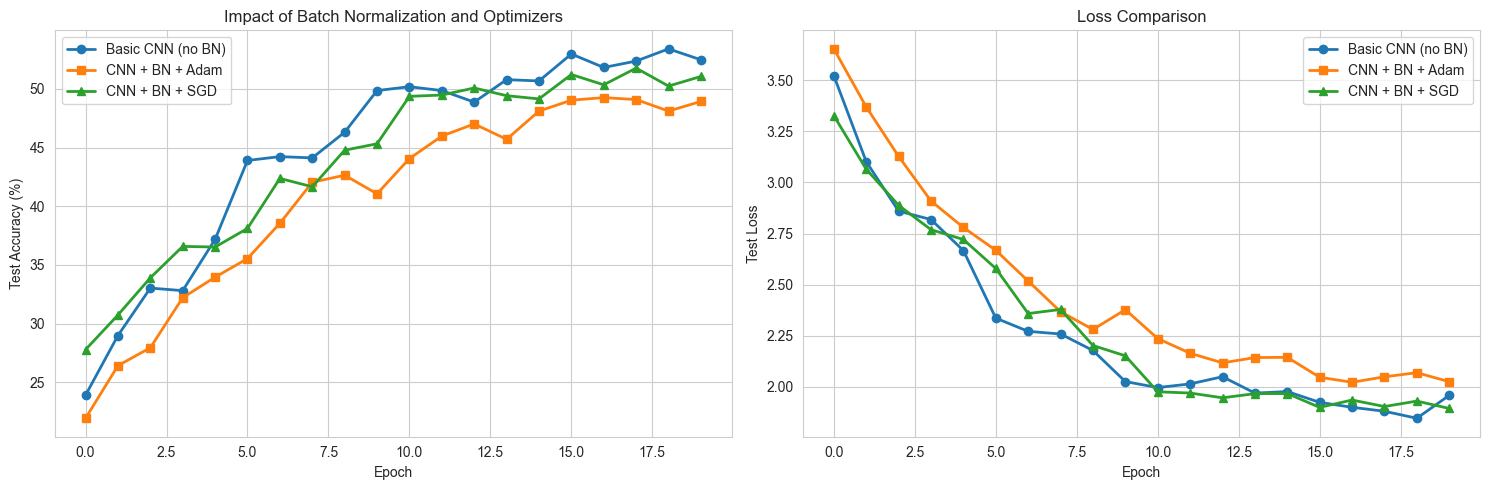


Performance Summary:
Basic CNN (no BN): 52.49%
CNN + BN + Adam: 48.93%
CNN + BN + SGD: 51.07%


In [23]:
## Compare all results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Test accuracy comparison
ax1.plot(history_basic['test_acc'], label='Basic CNN (no BN)', marker='o', linewidth=2)
ax1.plot(history_bn_adam['test_acc'], label='CNN + BN + Adam', marker='s', linewidth=2)
ax1.plot(history_bn_sgd['test_acc'], label='CNN + BN + SGD', marker='^', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Impact of Batch Normalization and Optimizers')
ax1.legend()
ax1.grid(True)

# Test loss comparison
ax2.plot(history_basic['test_loss'], label='Basic CNN (no BN)', marker='o', linewidth=2)
ax2.plot(history_bn_adam['test_loss'], label='CNN + BN + Adam', marker='s', linewidth=2)
ax2.plot(history_bn_sgd['test_loss'], label='CNN + BN + SGD', marker='^', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Loss')
ax2.set_title('Loss Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\nPerformance Summary:")
print(f"Basic CNN (no BN): {history_basic['test_acc'][-1]:.2f}%")
print(f"CNN + BN + Adam: {history_bn_adam['test_acc'][-1]:.2f}%")
print(f"CNN + BN + SGD: {history_bn_sgd['test_acc'][-1]:.2f}%")

### Question 2: Batch Normalization and Optimizers

**a) What is batch normalization and how does it help during training? What are the key benefits you observed in your experiments?**

$\color{blue}{\textit{Your Answer:}}$

Batch normalization normalizes a layers activation before passing it as an input to the next layer so that the data is not to "volatile" in a sense. This will enable the hyperparameters to learn the features better. We saw quicker convergence with the normalized data.


**b) Compare the performance of Adam vs SGD with momentum. Which one converges faster? Which achieves better final accuracy? Explain why.**

$\color{blue}{\textit{Your Answer:}}$

The SGD converges the quickest and with higher accuracy than Adam. SGD /w momentum tends towards flatter minima while Adam tends towards the sharper minima. This makes SGD w/ momentum generally better at generalization than Adam. 

## Part 6: ResNet and Residual Connections

**TODO: Implement a ResNet-style architecture with residual blocks**

Residual connections (skip connections) allow gradients to flow more easily through deep networks, enabling training of much deeper architectures.

In [37]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        """
        Residual Block with skip connection

        Args:
            in_channels: Number of input channels
            out_channels: Number of output channels
            stride: Stride for the first conv layer (for downsampling)
        """
        super(ResidualBlock, self).__init__()

        ################################################################################
        # TODO: Implement residual block
        # HINT: Use two 3x3 conv layers with batch norm and ReLU
        # Pattern: conv -> bn -> relu -> conv -> bn -> ADD -> relu
        # If stride != 1 or in_channels != out_channels, use a 1x1 conv for the shortcut
        ################################################################################
        # *****START OF YOUR CODE*****
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass with skip connection
        # HINT: identity = x (or through shortcut if needed), out = F(x) + identity
        ################################################################################
        # *****START OF YOUR CODE*****
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x) 
        out = F.relu(out)
        return out
        # *****END OF YOUR CODE*****
        ################################################################################


class SimpleResNet(nn.Module):
    def __init__(self, num_classes=101):
        """
        Simple ResNet for Caltech-101
        """
        super(SimpleResNet, self).__init__()

        ################################################################################
        # TODO: Build ResNet using ResidualBlocks
        # HINT: Start with a conv layer, then stack residual blocks, then FC layer
        # Suggested architecture:
        # - Initial conv: 3 -> 32 channels
        # - ResBlock1: 32 -> 32 (x2 blocks)
        # - ResBlock2: 32 -> 64 with stride=2 (downsample), then 64 -> 64
        # - ResBlock3: 64 -> 128 with stride=2 (downsample), then 128 -> 128
        # - Global average pooling
        # - FC layer to num_classes
        ################################################################################
        # *****START OF YOUR CODE*****
        self.conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(32)
        self.ResBlock1 = ResidualBlock(in_channels=32, out_channels=32)
        self.ResBlock2 = ResidualBlock(in_channels=32, out_channels=64, stride=2)
        self.ResBlock3 = ResidualBlock(in_channels=64, out_channels=128, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc1 = nn.Linear(128, num_classes)
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass
        ################################################################################
        # *****START OF YOUR CODE*****
        x = F.relu(self.bn(self.conv(x)))
        x = self.ResBlock1(x)
        x = self.ResBlock2(x)
        x = self.ResBlock3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)

        return x
        # *****END OF YOUR CODE*****
        ################################################################################

    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test the model
model_resnet = SimpleResNet(num_classes=num_classes)
print(f'ResNet architecture:\n{model_resnet}')
print(f'Number of parameters: {model_resnet.get_num_parameters():,}')

# Test forward pass
sample_batch = torch.randn(8, 3, 32, 32)
output = model_resnet(sample_batch)
print(f'Input shape: {sample_batch.shape}')
print(f'Output shape: {output.shape}')

ResNet architecture:
SimpleResNet(
  (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (ResBlock1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
  )
  (ResBlock2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

## Part 7: Regularization Techniques

**TODO: Apply regularization techniques to prevent overfitting**

Common regularization techniques include:
- Dropout
- Weight decay (L2 regularization)
- Data augmentation (already applied in transforms)
- Early stopping

In [43]:
class RegularizedResNet(nn.Module):
    def __init__(self, num_classes=101, dropout_rate=0.5):
        """
        ResNet with Dropout regularization

        Args:
            num_classes: Number of output classes
            dropout_rate: Dropout probability
        """
        super(RegularizedResNet, self).__init__()

        ################################################################################
        # TODO: Add dropout layers to SimpleResNet
        # HINT: Add dropout before the final FC layer
        # Copy the architecture from SimpleResNet and add nn.Dropout
        ################################################################################
        # *****START OF YOUR CODE*****
        self.conv = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn = nn.BatchNorm2d(32)
        self.ResBlock1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.ResBlock2 = nn.Sequential(ResidualBlock(in_channels=32, out_channels=64, stride=2), ResidualBlock(64, 64))
        self.ResBlock3 = nn.Sequential(ResidualBlock(in_channels=64, out_channels=128, stride=2), ResidualBlock(128, 128))
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc1 = nn.Linear(128, num_classes)
        # *****END OF YOUR CODE*****
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO: Implement forward pass with dropout
        ################################################################################
        # *****START OF YOUR CODE*****
        x = F.relu(self.bn(self.conv(x)))
        x = self.ResBlock1(x)
        x = self.ResBlock2(x)
        x = self.ResBlock3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc1(x)

        return x
        # *****END OF YOUR CODE*****
        ################################################################################

    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [44]:
print("="*60)
print("EXPERIMENT 4: ResNet WITHOUT Regularization")
print("="*60)

################################################################################
# TODO: Train SimpleResNet without dropout
################################################################################
# *****START OF YOUR CODE*****
model_resnet_no_reg = SimpleResNet(num_classes=num_classes)
optimizer_resnet = optim.SGD(model_resnet_no_reg.parameters(), lr=0.01, momentum=0.9)
model_resnet_no_reg.to(device)
# *****END OF YOUR CODE*****
################################################################################

history_resnet_no_reg = train_model(
    model_resnet_no_reg, train_loader, test_loader,
    optimizer_resnet, criterion, num_epochs=30, device=device
)

print("\n" + "="*60)
print("EXPERIMENT 5: ResNet WITH Dropout Regularization")
print("="*60)

################################################################################
# TODO: Train RegularizedResNet with dropout=0.5
################################################################################
# *****START OF YOUR CODE*****
model_resnet_reg = RegularizedResNet(num_classes=num_classes, dropout_rate=0.5)
optimizer_resnet_reg = optim.SGD(model_resnet_reg.parameters(), lr=0.01, momentum=0.9)
model_resnet_reg.to(device)
# *****END OF YOUR CODE*****
################################################################################

history_resnet_reg = train_model(
    model_resnet_reg, train_loader, test_loader,
    optimizer_resnet_reg, criterion, num_epochs=30, device=device
)

print("\n" + "="*60)
print("EXPERIMENT 6: ResNet WITH Dropout + Weight Decay")
print("="*60)

################################################################################
# TODO: Train with both dropout and weight decay
# HINT: Add weight_decay parameter to optimizer
################################################################################
# *****START OF YOUR CODE*****
model_resnet_reg_wd = RegularizedResNet(num_classes=num_classes, dropout_rate=0.2)
optimizer_resnet_reg_wd = optim.AdamW(model_resnet_reg_wd.parameters(), lr=1e-3, weight_decay=1e-4)
model_resnet_reg_wd.to(device)
# *****END OF YOUR CODE*****
################################################################################

history_resnet_reg_wd = train_model(
    model_resnet_reg_wd, train_loader, test_loader,
    optimizer_resnet_reg_wd, criterion, num_epochs=30, device=device
)


EXPERIMENT 6: ResNet WITH Dropout + Weight Decay


Epoch [1/30] - Train Loss: 3.7210, Train Acc: 23.02% - Test Loss: 3.8341, Test Acc: 21.82%


Epoch [2/30] - Train Loss: 3.3521, Train Acc: 27.01% - Test Loss: 3.5503, Test Acc: 27.83%


Epoch [3/30] - Train Loss: 3.1709, Train Acc: 29.72% - Test Loss: 3.1237, Test Acc: 30.07%


Epoch [4/30] - Train Loss: 2.9841, Train Acc: 31.95% - Test Loss: 2.9779, Test Acc: 31.33%


...

Epoch [26/30] - Train Loss: 1.5027, Train Acc: 60.23% - Test Loss: 1.7724, Test Acc: 54.95%


Epoch [27/30] - Train Loss: 1.4902, Train Acc: 60.89% - Test Loss: 1.8693, Test Acc: 54.07%


Epoch [28/30] - Train Loss: 1.4384, Train Acc: 63.03% - Test Loss: 1.7111, Test Acc: 55.71%


Epoch [29/30] - Train Loss: 1.4696, Train Acc: 61.42% - Test Loss: 1.6307, Test Acc: 56.70%


Epoch [30/30] - Train Loss: 1.3933, Train Acc: 62.35% - Test Loss: 1.7168, Test Acc: 56.15%


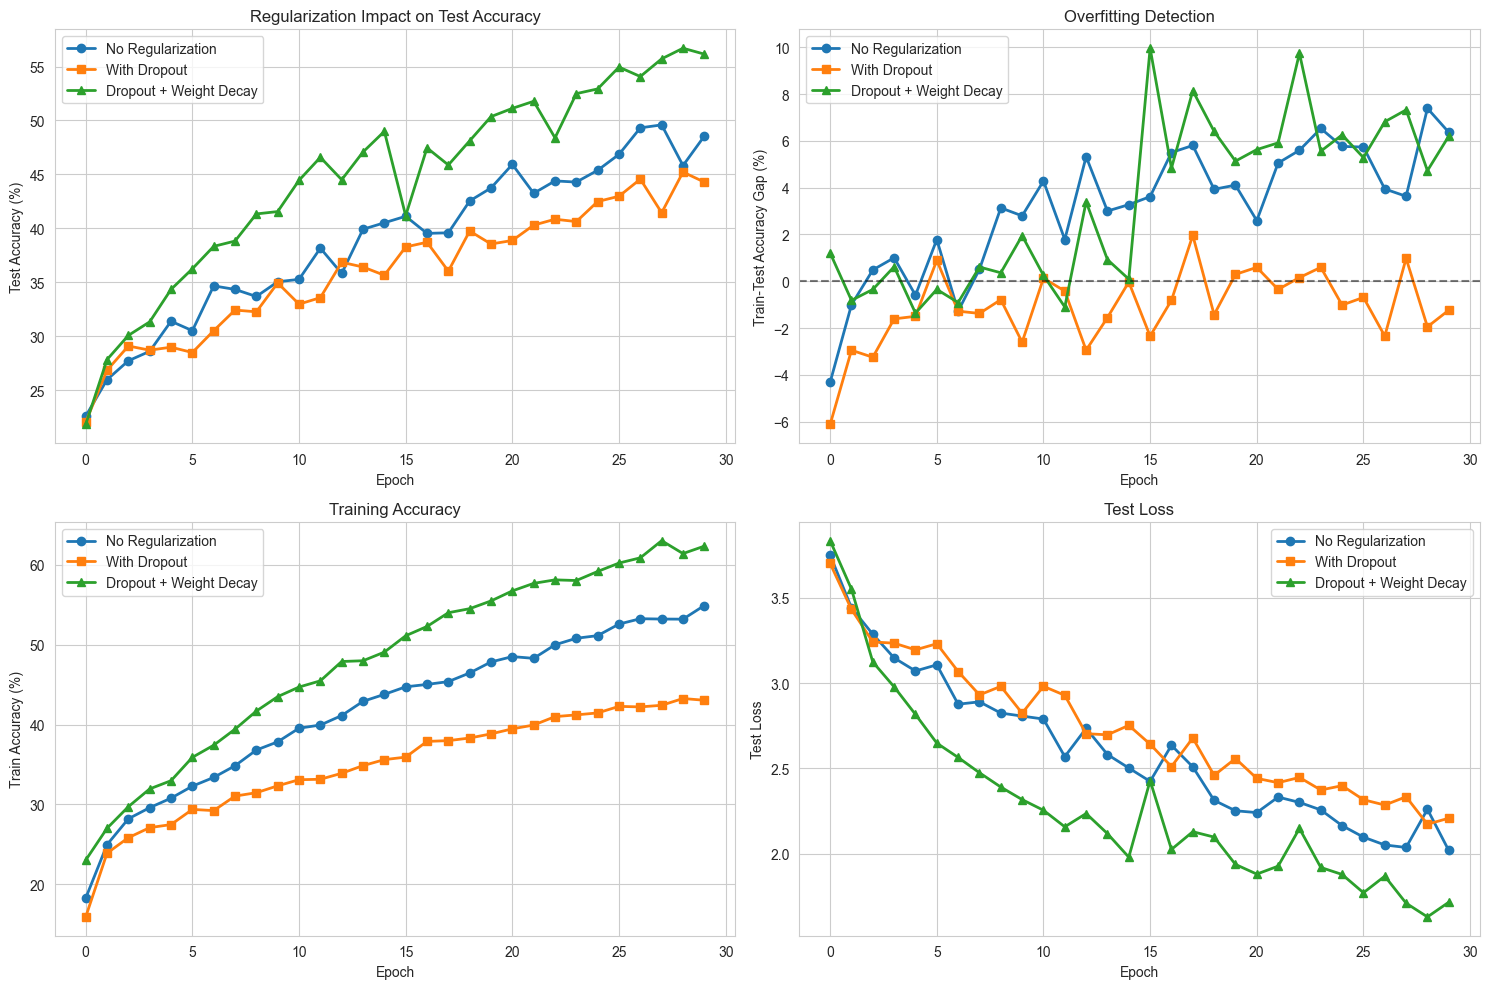


Regularization Summary:
No Regularization: Test Acc = 48.55%, Train-Test Gap = 6.36%
With Dropout: Test Acc = 44.29%, Train-Test Gap = -1.24%
Dropout + Weight Decay: Test Acc = 56.15%, Train-Test Gap = 6.20%


In [45]:
# Compare regularization effects
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Test accuracy
ax1.plot(history_resnet_no_reg['test_acc'], label='No Regularization', marker='o', linewidth=2)
ax1.plot(history_resnet_reg['test_acc'], label='With Dropout', marker='s', linewidth=2)
ax1.plot(history_resnet_reg_wd['test_acc'], label='Dropout + Weight Decay', marker='^', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Regularization Impact on Test Accuracy')
ax1.legend()
ax1.grid(True)

# Train vs Test gap (overfitting detection)
gap_no_reg = np.array(history_resnet_no_reg['train_acc']) - np.array(history_resnet_no_reg['test_acc'])
gap_reg = np.array(history_resnet_reg['train_acc']) - np.array(history_resnet_reg['test_acc'])
gap_reg_wd = np.array(history_resnet_reg_wd['train_acc']) - np.array(history_resnet_reg_wd['test_acc'])

ax2.plot(gap_no_reg, label='No Regularization', marker='o', linewidth=2)
ax2.plot(gap_reg, label='With Dropout', marker='s', linewidth=2)
ax2.plot(gap_reg_wd, label='Dropout + Weight Decay', marker='^', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Train-Test Accuracy Gap (%)')
ax2.set_title('Overfitting Detection')
ax2.legend()
ax2.grid(True)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Train accuracy
ax3.plot(history_resnet_no_reg['train_acc'], label='No Regularization', marker='o', linewidth=2)
ax3.plot(history_resnet_reg['train_acc'], label='With Dropout', marker='s', linewidth=2)
ax3.plot(history_resnet_reg_wd['train_acc'], label='Dropout + Weight Decay', marker='^', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Train Accuracy (%)')
ax3.set_title('Training Accuracy')
ax3.legend()
ax3.grid(True)

# Loss comparison
ax4.plot(history_resnet_no_reg['test_loss'], label='No Regularization', marker='o', linewidth=2)
ax4.plot(history_resnet_reg['test_loss'], label='With Dropout', marker='s', linewidth=2)
ax4.plot(history_resnet_reg_wd['test_loss'], label='Dropout + Weight Decay', marker='^', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Test Loss')
ax4.set_title('Test Loss')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

print("\nRegularization Summary:")
print(f"No Regularization: Test Acc = {history_resnet_no_reg['test_acc'][-1]:.2f}%, Train-Test Gap = {gap_no_reg[-1]:.2f}%")
print(f"With Dropout: Test Acc = {history_resnet_reg['test_acc'][-1]:.2f}%, Train-Test Gap = {gap_reg[-1]:.2f}%")
print(f"Dropout + Weight Decay: Test Acc = {history_resnet_reg_wd['test_acc'][-1]:.2f}%, Train-Test Gap = {gap_reg_wd[-1]:.2f}%")

### Question 3: ResNet and Regularization

**a) Explain how residual connections work and why they enable training of deeper networks. What problem do they solve?**

$\color{blue}{\textit{Your Answer:}}$

As you train a deep network, it becomes easier for it to produce vanishing gradients the deeper it becomes. So, instead of using a simple $H(x) = F(x)$ formula, we can add the input to the activation to get $H(x) = F(x) + x$. When $F(x) = 0$, $H(x) = x$ which makes that layer "ignored", rather than causing a vanishing gradient problem.

**b) Compare the regularization techniques you tested (dropout, weight decay). Which was most effective at reducing overfitting? How can you tell from the training curves?**

$\color{blue}{\textit{Your Answer:}}$

Dropout with decay worked the best for overfitting as the regularization techniques helped to generalize the data more. You can tell by looking at the training accuracy vs the testing accuracy.

**c) What is the trade-off between model capacity and regularization? How do you decide on the right amount of regularization?**

$\color{blue}{\textit{Your Answer:}}$

At the end of the day, you have to look at the training curves to have a good sense of the right amount of regularization. By looking at the accuracies in relation to each other, you can determine which hyperparameters need to be changed.

## Part 8: Performance Challenge

**TODO: Achieve at least 56% test accuracy on Caltech-101**

Use everything you've learned to build and train the best model you can. You may:
- Modify the architecture (add more layers, change channel sizes, etc.)
- Experiment with different optimizers and learning rates
- Apply different regularization techniques
- Use learning rate scheduling
- Train for more epochs

**Document your approach and final configuration below.**

**Note:** Caltech-101 with 101 classes is more challenging than CIFAR-10. A 56%+ accuracy demonstrates solid understanding of CNN fundamentals.

Epoch [1/30] - Train Loss: 3.7538, Train Acc: 21.41% - Test Loss: 4.0284, Test Acc: 23.67%


Epoch [2/30] - Train Loss: 3.3431, Train Acc: 27.27% - Test Loss: 3.1700, Test Acc: 28.87%


Epoch [3/30] - Train Loss: 3.1459, Train Acc: 29.58% - Test Loss: 3.4026, Test Acc: 28.76%


Epoch [4/30] - Train Loss: 2.9858, Train Acc: 31.83% - Test Loss: 2.9674, Test Acc: 31.00%


Epoch [5/30] - Train Loss: 2.8653, Train Acc: 33.42% - Test Loss: 2.9765, Test Acc: 33.19%


...

Epoch [26/30] - Train Loss: 1.5453, Train Acc: 59.62% - Test Loss: 1.8027, Test Acc: 54.13%


Epoch [27/30] - Train Loss: 1.4912, Train Acc: 60.92% - Test Loss: 1.7721, Test Acc: 54.40%


Epoch [28/30] - Train Loss: 1.4527, Train Acc: 61.97% - Test Loss: 1.6319, Test Acc: 56.59%


Epoch [29/30] - Train Loss: 1.3782, Train Acc: 63.40% - Test Loss: 1.7004, Test Acc: 56.31%


Epoch [30/30] - Train Loss: 1.3823, Train Acc: 63.79% - Test Loss: 1.8272, Test Acc: 57.35%


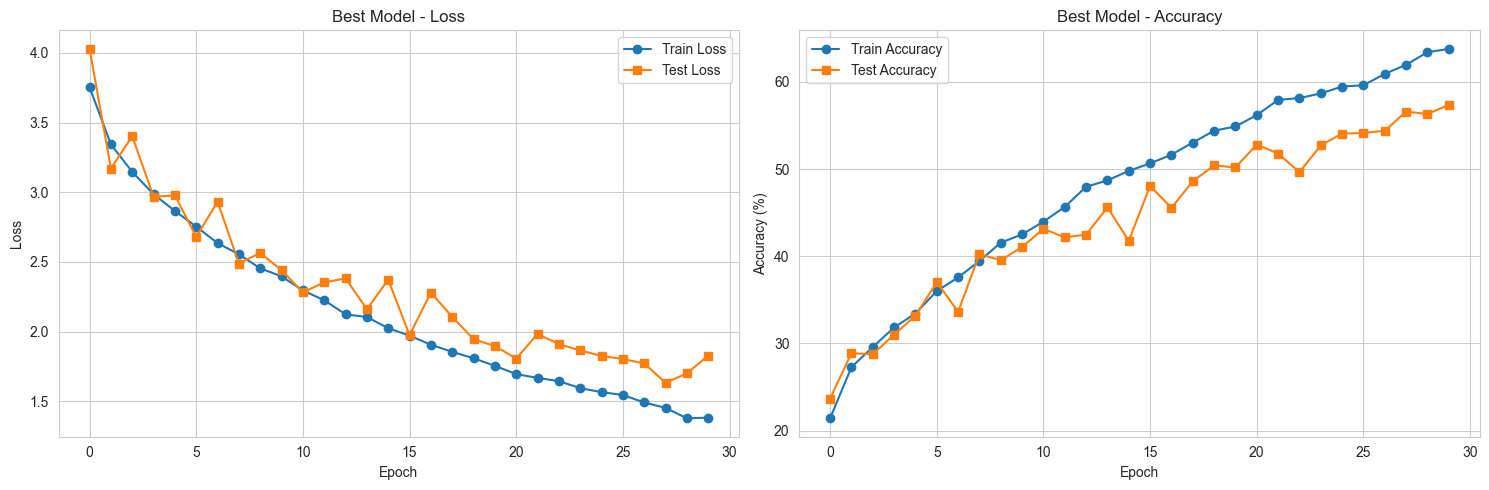


FINAL BEST MODEL PERFORMANCE
Best Test Accuracy: 57.35%
Final Test Accuracy: 57.35%
Number of Parameters: 708,518


In [48]:
################################################################################
# TODO: Build and train your best model
# Target: >= 56% test accuracy on Caltech-101
# Document your architecture choices and hyperparameters
################################################################################
# *****START OF YOUR CODE*****

# Define your model
best_model = RegularizedResNet(num_classes=num_classes, dropout_rate=0.2)

# Define optimizer
optimizer_best = optim.AdamW(best_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Optional: Add learning rate scheduler
scheduler_best = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_resnet_reg_wd, 
    T_max=30
)

# Train the model
num_epochs_best = 30  # Adjust as needed

# Architecture explanation:
# TODO: Document your architecture and hyperparameter choices here

# I chose RegularizedResNet so I could take full advantage of the skip neurons to escape vanishing gradients while still having the dropout
# neurons to address underfitting.
# Hyperparameter choices:
# - dropout_rate = 0.2 since we are working with a fairly small network, I do not want poor generalization, which dropping half 
# the neurons would give
# - lr = 0.001 (1e-3) so the system is not erratic
# - weight_decay = 0.0001 (1e-4) so the weights can change moderately with the small dataset

# *****END OF YOUR CODE*****
################################################################################

history_best = train_model(
    best_model, train_loader, test_loader,
    optimizer_best, criterion, num_epochs=num_epochs_best,
    device=device, scheduler=scheduler_best
)

plot_training_history(history_best, "Best Model")

print("\n" + "="*60)
print("FINAL BEST MODEL PERFORMANCE")
print("="*60)
print(f"Best Test Accuracy: {max(history_best['test_acc']):.2f}%")
print(f"Final Test Accuracy: {history_best['test_acc'][-1]:.2f}%")
print(f"Number of Parameters: {best_model.get_num_parameters():,}")

### Question 4: Model Optimization

**a) Describe your final architecture and hyperparameter choices. Why did you make these decisions?**

$\color{blue}{\textit{Your Answer:}}$

I chose the RegularizedResNet architecture to take full advantage of addressing the effects of vanishing gradients.
**Hyperparameter choices:**
    - dropout_rate = 0.2 since we are working with a fairly small network, I do not want poor generalization, which dropping half 
    the neurons would give
    - lr = 0.001 (1e-3) so the system is not erratic
    - weight_decay = 0.0001 (1e-4) so the weights can change moderately with the small dataset

**b) What were the most impactful changes you made to improve performance?**

$\color{blue}{\textit{Your Answer:}}$

The most impactful changes was the weight_decay and dropout_rate. By reducing the dropout_rate from 0.5 to 0.2 and the weight_decay from 1e-3 to 1e-4, I saw much better results.

**c) If you had more time and computational resources, what would you try next to further improve the model?**

$\color{blue}{\textit{Your Answer:}}$

More epochs, lower learning rater, and potentially adding more sequences in the network.